# Pairs trading with transaction costs

What is pairs trading? 

[Pairs trading](https://www.investopedia.com/terms/p/pairstrade.asp) is a market neutral trading strategy—it seeks to avoid some form of market risk entirely, typically by hedging—that involves taking simultaneously a long position with a short one in two highly correlated stocks or assets, this is crucial for the strategy, but finding and maintaining two assets that have a high correlation can be challenging.

> The strategy monitors performance of two historically correlated securities. When the correlation between the two securities temporarily weakens, i.e. one stock moves up while the other moves down, the pairs trade would be to short the outperforming stock and to long the underperforming one, betting that the "spread" between the two would eventually converge. [1]

The divergence within a pair can be caused by temporary supply/demand changes, large buy/sell orders for one security, reaction for important news about one of the companies, and so on.

> The reason for the deviated stock to come back to original value is itself an assumption. It is assumed that the pair will have similar business performance as in the past during the holding period of the stock.

**Potential drawbacks of the strategy:**

- The divergence between the prices of the securities can be a rational response to news related to one of the securities, invalidating the reversion to the mean assumption.
- Scarcity of opportunities
- Compete with HFT funds

Depending on the market sector, there exists multiple reasons for which two historically correlated securities can have differences on it's stock prices, e.g., company A's management could be extremely efficient while company B's management could be not efficient, this can cause stock A to rise and stock B to fall, and in this case it is not certain that stock B could go back to its mean since it's a management efficiency issue, hence shorting A and buying B would result in a potential loss. 

**Characteristics** 

- Pairs trading is a mean reverting strategy, betting that the prices will eventually return to historical trends, i.e., overperforming stock will do down to its historical mean and underperforming stock will go up to its historical mean

- Pairs trade can hedge sector and market risks, e.g., in case of a market crash, and the two positions going down with it, the trade would result in a gain on the short position and a loss on the long position, leaving a net profit close to breakeven.

**Potentially correlated pairs:**

- Coca Cola and Pepsi
- Walmart and Target
- Dell and HP
- Ford and General Motors

According to Skiena, highly-correlated pairs often (but not always) come from the same sector because they face similar systematic risks.

**Example:** 

> Pepsi (PEP) and Coca-Cola (KO) are different companies that create a similar product, soda pop. Historically, the two companies have shared similar dips and highs, depending on the soda pop market. If the price of Coca-Cola were to go up a significant amount while Pepsi stayed the same, a pairs trader would buy Pepsi stock and sell Coca-Cola stock, assuming that the two companies would later return to their historical balance point. If the price of Pepsi rose to close that gap in price, the trader would make money on the Pepsi stock, while if the price of Coca-Cola fell, they would make money on having shorted the Coca-Cola stock. [2]

## References
<a id="1">[1]</a> 
Skiena, S. 
[Lecture on pairs trading](https://www3.cs.stonybrook.edu/~skiena/691/lectures/lecture23.pdf)

<a id="2">[2]</a> 
Wikipedia. [Pair trading](https://en.wikipedia.org/wiki/Pairs_trade)




# PINN Implementation

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.autograd import grad
import torch.optim as optim
import math
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.set_default_dtype(torch.float64)

# Model parameters
param = {
    # Initial condition
    'p0': 1,
    "mu": 0.2,
    "sigma": 0.4,
    "theta": 0.1,
    "kappa": 1.0,
    "nu": 0.15,
    "rho": 0.5,
    "r": 0.01,
    "gamma": 5.0,
    # Transaction cost params
    "ap": 1.0005,  # ap = 1 + zeta_p
    "bp": 0.9995,  # bp = 1 - eta_p
    "aq": 1.0005,  # aq = 1 + zeta_q
    "bq": 0.9995,  # bq = 1 - eta_q
    # Domain
    "T": 1.0
}

# A_minus and A_plus
def A_minus(p, x):
    # A- = (a_p - b_q * exp(x)) * p
    return (param["ap"] - param["bq"] * torch.exp(x)) * p

def A_plus(p, x):
    # A+ = (b_p - a_q * exp(x)) * p
    return (param["bp"] - param["aq"] * torch.exp(x)) * p

# Terminal payoff, i.e., liquidated value of the portfolio
# J(p(T), x(T), y(T)) = A+ * y 1{y>=0} + A- * y 1{y<0}
def terminal_J(p, x, y):
    return torch.where(y >= 0, A_plus(p, x) * y, A_minus(p, x) * y)

# Neural network for u(t,p,x,y) = log H(t, p, x, y)
class Net(nn.Module):
    def __init__(self, n_in, n_out=1, layers=[64, 64, 64]):
        super().__init__()
        seq = [nn.Linear(n_in, layers[0]), nn.Tanh()]
        for i in range(len(layers)-1):
            seq += [nn.Linear(layers[i], layers[i+1]), nn.Tanh()]
        seq.append(nn.Linear(layers[-1], n_out))
        self.net = nn.Sequential(*seq)
    def forward(self, *args):
        x = torch.cat([a if a.ndim > 1 else a.unsqueeze(1) for a in args], dim=1)
        return self.net(x).squeeze(-1)
    
class BoundaryNet(nn.Module):         # SINGLE network → (center, width) → (Yb, Ys)
    def __init__(self):
        super().__init__()
        self.center = nn.Sequential(
            nn.Linear(3, 80), nn.Tanh(),
            nn.Linear(80, 80), nn.Tanh(),
            nn.Linear(80, 80), nn.Tanh(),
            nn.Linear(80, 1)
        )
        self.width = nn.Sequential(      # Forces positive width → Yb < Ys always
            nn.Linear(3, 80), nn.Tanh(),
            nn.Linear(80, 80), nn.Tanh(),
            nn.Linear(80, 80), nn.Tanh(),
            nn.Linear(80, 1),
            nn.Softplus()
        )
        
    def forward(self, t, p, x):
        inp = torch.cat([t.unsqueeze(1), p.unsqueeze(1), x.unsqueeze(1)], dim=1)
        center = self.center(inp).squeeze(-1)
        width  = self.width(inp).squeeze(-1) + 0.5   # minimum width 0.5 → prevents collapse
        return center - width/2, center + width/2   # Yb, Ys


net_u  = Net(4).to(device)          # u = log H(t,p,x,y)
net_bound = BoundaryNet().to(device)

# Domain bounds
t_min, t_max = 0.0, param['T']
p_min, p_max = 0.3, 4.0
x_min, x_max = -0.5, 0.5
y_min, y_max = -10, 10

# Sample function for t, p, x
def sample_tpx(batch_size):
    t = torch.rand(batch_size, device=device) * (t_max - t_min) + t_min
    p = torch.rand(batch_size, device=device) * (p_max - p_min) + p_min
    x = torch.rand(batch_size, device=device) * (x_max - x_min) + x_min
    t.requires_grad = True
    p.requires_grad = True
    x.requires_grad = True
    return t, p, x

# PDE residual for u = log H (transformed L_{2,o} H = 0)
def pde_residual(u, t, p, x, y):
    grads = torch.autograd.grad(u, (t, p, x, y), 
                               grad_outputs=torch.ones_like(u),
                               create_graph=True, retain_graph=True)
    du_t, du_p, du_x = grads[0], grads[1], grads[2]

    # Second derivatives
    du_pp = torch.autograd.grad(du_p, p, torch.ones_like(du_p), create_graph=True)[0]
    du_xx = torch.autograd.grad(du_x, x, torch.ones_like(du_x), create_graph=True)[0]
    du_px = torch.autograd.grad(du_p, x, torch.ones_like(du_p), create_graph=True)[0]

    res = (du_t
            + param["kappa"]*(param["theta"] - x)*du_x
            + param["mu"]*p*du_p
            + 0.5*param["nu"]**2 * (du_xx + du_x**2)
            + param["rho"]*param["nu"]*param["sigma"]*p * (du_px + du_p*du_x)
            + 0.5*(param["sigma"]*p)**2 * (du_pp + du_p**2))
    return res

# 2. Loss weights
w_pde   = 1
w_buy   = 10      
w_sell  = 10     
w_bc    = 5
w_term  = 1

# Loss function
def compute_loss(n_batch=2000, delta_out=4.0):
    # Common points
    t, p, x = sample_tpx(n_batch)
    yb, ys = net_bound(t, p, x)

    # No-transaction region (interior)
    mask = yb < ys
    if mask.any():
        t_i, p_i, x_i, yb_i, ys_i = t[mask], p[mask], x[mask], yb[mask], ys[mask]
        # Fresh leaf variable for y
        xi = torch.rand_like(yb_i)
        y_i = yb_i + xi * (ys_i - yb_i)
        y_i.requires_grad_(True)                   
        u_i = net_u(t_i, p_i, x_i, y_i)
        loss_pde = torch.mean(pde_residual(u_i, t_i, p_i, x_i, y_i)**2)
    else:
        loss_pde = torch.tensor(0.0, device=device)

    # Buy region
    y_buy = yb - torch.rand_like(yb) * delta_out
    y_buy.requires_grad_(True)
    u_buy = net_u(t, p, x, y_buy)   # u(t,p,x,y)  where y = log H at a point inside buy region
    u_b   = net_u(t, p, x, yb)      # u(t,p,x,Y_b) = log H on the buy boundary
    target_buy = u_b - param["gamma"] * torch.exp(param["r"]*(param["T"]-t)) * A_minus(p, x) * (y_buy - yb)
    loss_buy = torch.mean((u_buy - target_buy)**2)

    # Sell region
    y_sell = ys + torch.rand_like(ys) * delta_out
    y_sell.requires_grad_(True)
    u_sell = net_u(t, p, x, y_sell)
    u_s   = net_u(t, p, x, ys)
    target_sell = u_s - param["gamma"] * torch.exp(param["r"]*(param["T"]-t)) * A_plus(p, x) * (y_sell - ys)
    loss_sell = torch.mean((u_sell - target_sell)**2)

    # Boundary conditions (smooth pasting)
    # buy boundary
    yb_bc = yb.clone().detach().requires_grad_(True)
    ys_bc = ys.clone().detach().requires_grad_(True)
    grad_b = torch.autograd.grad(net_u(t,p,x,yb_bc), yb_bc, torch.ones_like(yb_bc), create_graph=True)[0]
    grad_s = torch.autograd.grad(net_u(t,p,x,ys_bc), ys_bc, torch.ones_like(ys_bc), create_graph=True)[0]
    loss_sp = torch.mean((grad_b + param["gamma"]*torch.exp(param["r"]*(param["T"]-t))*A_minus(p,x))**2) + \
              torch.mean((grad_s + param["gamma"]*torch.exp(param["r"]*(param["T"]-t))*A_plus(p,x))**2)


    # Terminal condition
    y_term = torch.rand(n_batch, device=device) * (y_max - y_min) + y_min
    t_term = torch.full((n_batch,), param["T"], device=device)
    p_term, x_term = sample_tpx(n_batch)[1], sample_tpx(n_batch)[2]
    u_term = net_u(t_term, p_term, x_term, y_term)
    loss_term = torch.mean((u_term + param["gamma"] * terminal_J(p_term, x_term, y_term))**2)

    total = (w_pde  * loss_pde +
             w_buy * loss_buy +
             w_sell * loss_sell +
             w_bc * loss_sp +
             w_term * loss_term)
    
    return total


optimizer = torch.optim.Adam(list(net_u.parameters()) +
                            list(net_bound.parameters()), lr=8e-4)

scheduler = CosineAnnealingWarmRestarts(
    optimizer, 
    T_0=5000,      # First cycle length (epochs)
    T_mult=2,      # Each restart doubles the cycle length
    eta_min=1e-5   # Minimum LR (prevents stalling)
)

# Training loop
training_params = {'epochs': 40000,
                   'n_batch': 10000}

for epoch in range(training_params["epochs"]):
    optimizer.zero_grad()
    loss = compute_loss(n_batch=training_params["n_batch"])
    loss.backward()

    torch.nn.utils.clip_grad_norm_(list(net_u.parameters()) + list(net_bound.parameters()), 1.0)

    optimizer.step()
    #scheduler.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d}  loss = {loss.item():.3e}")

print("Training finished!")

c:\Users\Jujop\Documents\GitHub\ams-516\.venv\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch     0  loss = 2.963e+03
Epoch  1000  loss = 2.086e+02
Epoch  2000  loss = 6.218e+01
Epoch  3000  loss = 2.794e+01
Epoch  4000  loss = 1.532e+01
Epoch  5000  loss = 7.079e+00
Epoch  6000  loss = 2.119e+00
Epoch  7000  loss = 1.557e+00
Epoch  8000  loss = 1.039e+00
Epoch  9000  loss = 6.824e-01
Epoch 10000  loss = 5.643e-01
Epoch 11000  loss = 7.334e-01
Epoch 12000  loss = 3.057e-01
Epoch 13000  loss = 5.338e-01
Epoch 14000  loss = 3.541e-01
Epoch 15000  loss = 2.857e-01
Epoch 16000  loss = 2.506e-01
Epoch 17000  loss = 3.115e-01
Epoch 18000  loss = 2.909e-01
Epoch 19000  loss = 2.482e-01
Epoch 20000  loss = 2.365e-01
Epoch 21000  loss = 2.584e-01
Epoch 22000  loss = 3.043e-01
Epoch 23000  loss = 2.724e-01
Epoch 24000  loss = 2.444e-01
Epoch 25000  loss = 1.938e-01
Epoch 26000  loss = 2.770e-01
Epoch 27000  loss = 4.451e-01
Epoch 28000  loss = 2.024e-01
Epoch 29000  loss = 2.190e-01
Epoch 30000  loss = 1.763e-01
Epoch 31000  loss = 2.040e-01
Epoch 32000  loss = 1.764e-01
Epoch 3300

In [6]:
plt.rcParams['text.usetex'] = True

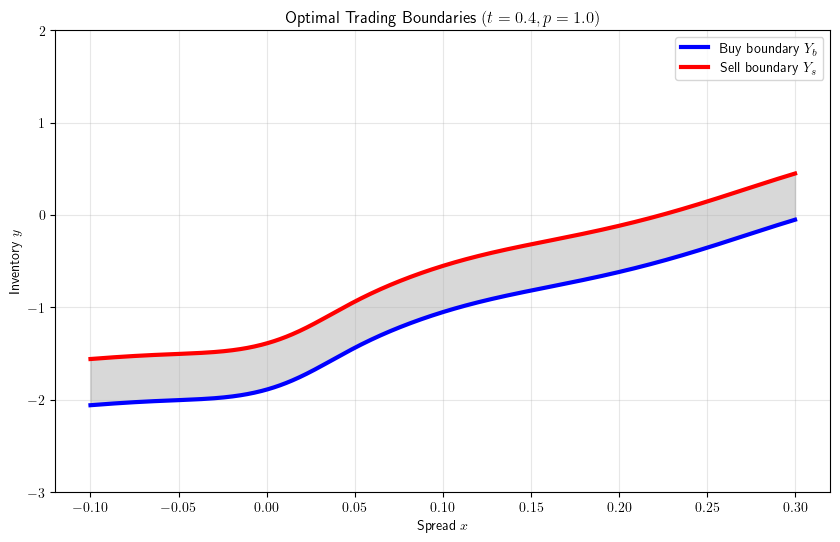

In [12]:
import matplotlib.pyplot as plt

t_plot = torch.full((800,), 0.4, device=device)
p_plot = torch.full((800,), 1.0, device=device)
x_plot = torch.linspace(-0.1, 0.3, 800, device=device)

with torch.no_grad():
    yb_plot, ys_plot = net_bound(t_plot, p_plot, x_plot)

plt.figure(figsize=(10,6))
plt.plot(x_plot.cpu().numpy(), yb_plot.cpu().numpy(), 'b-', lw=3, label='Buy boundary $Y_b$')
plt.plot(x_plot.cpu().numpy(), ys_plot.cpu().numpy(), 'r-', lw=3, label='Sell boundary $Y_s$')
plt.fill_between(x_plot.cpu().numpy(), yb_plot.cpu().numpy(), ys_plot.cpu().numpy(), alpha=0.3, color='gray')
plt.xlabel('Spread $x$'); plt.ylabel('Inventory $y$')
plt.title('Optimal Trading Boundaries $(t=0.4, p=1.0)$')
plt.legend(); plt.grid(alpha=0.3); plt.ylim(-3,2) 
plt.savefig('PINN_result1.png')
plt.show()

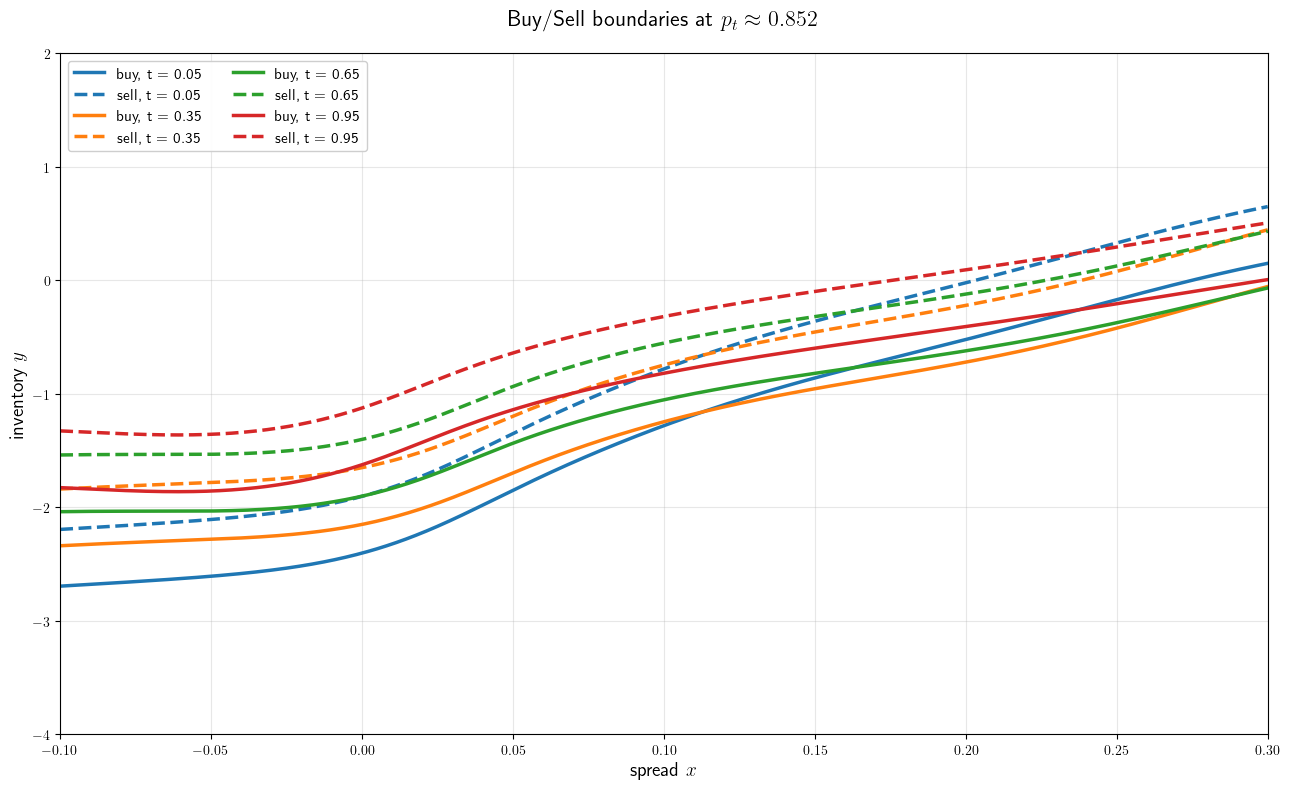

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# === SETTINGS ===
p_fixed = 0.852          # As in Xing's Figure 1
x_grid = torch.linspace(-0.10, 0.30, 1000, device=device)  # Focus on relevant spread range
times = [0.05, 0.35, 0.65, 0.95]   # Same as in the paper
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Classic matplotlib colors
labels = [f't = {t:.2f}' for t in times]

plt.figure(figsize=(13, 8))

with torch.no_grad():
    for i, t_val in enumerate(times):
        t_tensor = torch.full_like(x_grid, t_val)
        p_tensor = torch.full_like(x_grid, p_fixed)
        
        yb, ys = net_bound(t_tensor, p_tensor, x_grid)
        
        yb_np = yb.cpu().numpy()
        ys_np = ys.cpu().numpy()
        x_np  = x_grid.cpu().numpy()
        
        color = colors[i]
        
        # Buy boundary (lower)
        plt.plot(x_np, yb_np, color=color, linewidth=2.5, 
                 label=f'buy, {labels[i]}')
        
        # Sell boundary (upper)
        plt.plot(x_np, ys_np, color=color, linestyle='--', linewidth=2.5,
                 label=f'sell, {labels[i]}')

# === FINAL POLISH — exactly like Xing's figure ===
plt.xlabel('spread $x$', fontsize=14)
plt.ylabel('inventory $y$', fontsize=14)
plt.title(f'Buy/Sell boundaries at $p_t \\approx {p_fixed:.3f}$', fontsize=16, pad=20)

plt.xlim(-0.10, 0.30)
plt.ylim(-4, 2)
plt.grid(True, alpha=0.3)
# plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
# plt.axvline(0, color='black', linewidth=0.8, alpha=0.5)

# Custom legend: one entry per time, with solid + dashed
handles, legend_labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(legend_labels, handles))  # remove duplicates
sorted_items = sorted(by_label.items(), key=lambda x: float(x[0].split('=')[-1]))

# Reorder legend: buy then sell for each time
ordered_handles = []
ordered_labels  = []
for t in times:
    t_str = f't = {t:.2f}'
    ordered_labels.append(f'buy,  {t_str}')
    ordered_labels.append(f'sell, {t_str}')
    ordered_handles.append(by_label[f'buy, {t_str}'])
    ordered_handles.append(by_label[f'sell, {t_str}'])

plt.legend(ordered_handles, ordered_labels, 
           ncol=2, fontsize=11, loc='upper left', framealpha=0.95)

plt.tight_layout()
plt.savefig('PINN_result2.png')
plt.show()